<h1 align="center">Практическая работа№4</h1>

1. Выберите любой размеченный датасет на kaggle.com в формате .csv и скачайте его. Напишите программу, которая проведет предварительную обработку данных этого датасета и получите структуру данных (список, словарь, датафрейм, массив - по вашему выбору), содержащую только численные данные.

In [ ]:
import pandas as pd
import json
#Загрузка данных из файла
df = pd.read_csv("youtube.csv")

#Для удобства удалим нечисловые колонки
nums_df = df.select_dtypes(include=['number'])
#Преобразование в словарь
dict = nums_df.to_dict(orient='list')
#Созранение в json
with open("numer_data_json", "w") as f:
    json.dump(dict, f, indent=4)
print("Данные сохранились в json")

1. Выберите любой размеченный датасет на kaggle.com в формате .csv и скачайте его. 
2. Напишите программу, которая проведет предварительную обработку данных этого датасета и получите структуру данных (список, словарь, датафрейм, массив - по вашему выбору), содержащую только численные данные.
3. Сделайте предположения о распределениях значений признаков и проведите либо шкалирование, либо нормировку, по всем признакам (столбцам датафрейма). 
4. Постройте корреляционную матрицу.
5. Устраните выбросы в данных. 
6. Избавьтесь от тождественных и противоречивых экземпляров.
7. Снова постройте корреляционную матрицу - произошли ли изменения? 
8. Преобразуйте данные в целочисленную форму и сделайте размерность датасета равной 3.
9. Постройте корреляционную матрицу.
10. Просмотрите весь ваш код, проставьте комментарии и сделайте выводы после каждого построения корреляционной матрицы.

Данные сохранились в json


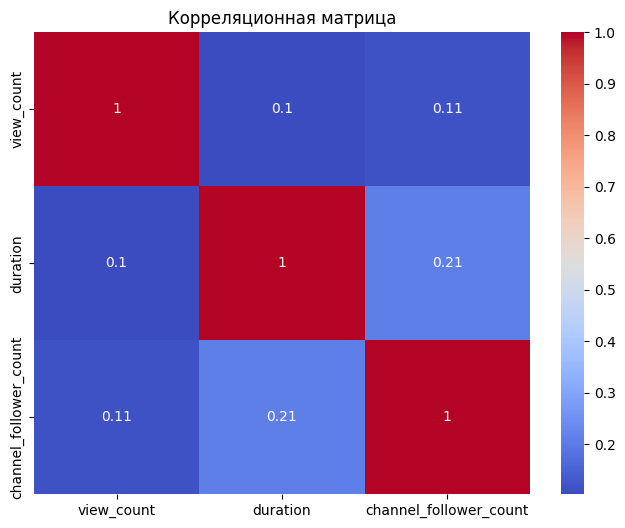

После удаления выбросов (88, 3)


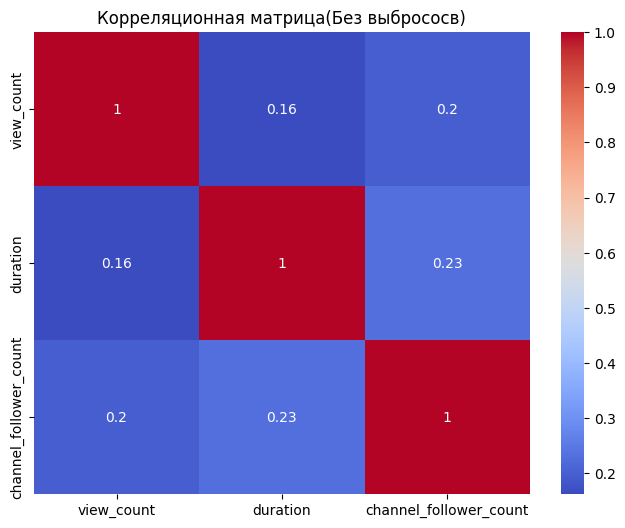

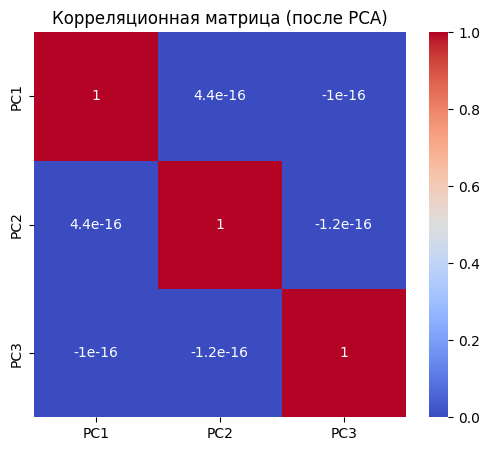

In [1]:
import pandas as pd
import json
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Загрузка данных из файла
df = pd.read_csv("youtube.csv")

#Для удобства удалим нечисловые колонки
nums_df = df.select_dtypes(include=['number'])
#Преобразование в словарь
dict = nums_df.to_dict(orient='list')
#Созранение в json
with open("numer_data_json", "w") as f:
    json.dump(dict, f, indent=4)
print("Данные сохранились в json")

#Предположение распределения и нормализация(приведение данных к диапазону[0,1])
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(nums_df)
scaler_df = pd.DataFrame(scaled_values, columns=nums_df.columns)

#Строим кореляционную матрицу
plt.figure(figsize=(8, 6))
sns.heatmap(scaler_df.corr(), annot = True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

#Устранение выбросов
Q1 = scaler_df.quantile(0.25)
Q3 = scaler_df.quantile(0.75)
IQR = Q3 - Q1
#фильтрация строк, не содержащих выбросы
filter_df = scaler_df[~((scaler_df < (Q1 - 1.5 * IQR)) | (scaler_df > (Q3 + 1.5* IQR))).any(axis=1)]
print(f"После удаления выбросов {filter_df.shape}")

#Удаляю дублирующиеся точки
filter_df = filter_df.drop_duplicates()

#Корреляционная матрица
plt.figure(figsize=(8, 6))
sns.heatmap(filter_df.corr(), annot = True, cmap="coolwarm")
plt.title("Корреляционная матрица(Без выбрососв)")
plt.show()

#Преобразуем данные в числа
int_df = (filter_df * 100).astype(int)
#Уменьшение размерности
pca = PCA(n_components=3)
reduced_data = pca.fit_transform(int_df)
reduced_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])

#Итоговая корреляционная матрица
plt.figure(figsize=(6,5))
sns.heatmap(reduced_df.corr(), annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица (после PCA)")
plt.show()